# Review Reply Workflow

In [3]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field

In [4]:
load_dotenv()

True

In [5]:
model = ChatOpenAI(model='gpt-4o-mini', temperature=1)

In [6]:
class SentimentSchema(BaseModel):

    sentiment: Literal['positive', 'negative'] = Field(description='Sentiment of the review')

In [7]:
class DiagnoiseSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [8]:
structured_model = model.with_structured_output(SentimentSchema)
structured_model2 = model.with_structured_output(DiagnoiseSchema)

In [9]:
prompt = 'What is the sentiment of the following review - The software too good'
structured_model.invoke(prompt)
# structured_model.invoke(prompt).sentiment

SentimentSchema(sentiment='positive')

In [10]:
class ReviewState(TypedDict):

    review: str
    sentiment: Literal['positive','negative']
    diagnosis: dict
    response: str

In [23]:
def find_sentiment(state: ReviewState) -> ReviewState:

    prompt = f"For the following review find out the sentiment \n {state['review']}"
    sentiment = structured_model.invoke(prompt).sentiment

    return {'sentiment': sentiment}

def check_sentiment(state: ReviewState) -> Literal['positive_response', 'run_diagnose']:

    if state['sentiment'] == 'positive':
        return 'positive_response'
    else:
        return 'run_diagnose'
    
def positive_response(state: ReviewState) -> ReviewState:
    
    prompt = f"""Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n
    Also, kindly ask the user to leave feedback on our website."""
    
    response = model.invoke(prompt).content

    return {'response': response}

def run_diagnose(state: ReviewState):

    prompt  = f"""Diagnose this negative review:\n\n{state['review' ]} \n"
    "Return issue_type, tone, and urgency."""

    response = structured_model2.invoke(prompt)

    return {'diagnosis': response.model_dump()}

def negative_response(state: ReviewState):

    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
    The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency. Write an empathetic, helpful resolution message."""

    response = model.invoke(prompt).content

    return {'response': response}    

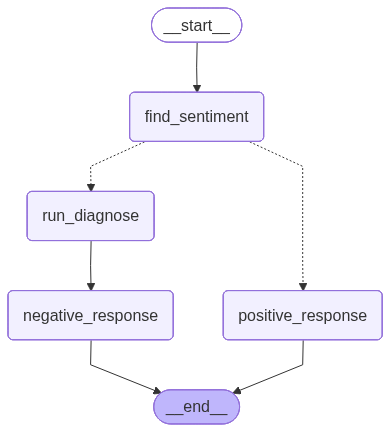

In [24]:
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment',find_sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('run_diagnose', run_diagnose)
graph.add_node('negative_response', negative_response)

graph.add_edge(START, 'find_sentiment')

graph.add_conditional_edges('find_sentiment', check_sentiment)

graph.add_edge('positive_response', END)

graph.add_edge('run_diagnose', 'negative_response')
graph.add_edge('negative_response', END)

graph.compile()

In [25]:
workflow = graph.compile()

In [26]:
initial_state = {
    'review': "I've been using this app for about a month now, and I must say, the user interface is incredibly clean and intuitive. Everything is exactly where you'd expect it to be. It's rare to find something that just works without needing a tutorial. Great job to the design team!"
}

workflow.invoke(initial_state)

{'review': "I've been using this app for about a month now, and I must say, the user interface is incredibly clean and intuitive. Everything is exactly where you'd expect it to be. It's rare to find something that just works without needing a tutorial. Great job to the design team!",
 'sentiment': 'positive',
 'response': "Dear [User's Name],\n\nThank you so much for your wonderful review! We're thrilled to hear that you find our app's user interface clean and intuitive. It's always our goal to create a seamless experience for our users, and your feedback validates the hard work our design team puts in.\n\nWe truly appreciate your support, and we'd love to hear more of your thoughts! If you have a moment, please consider leaving feedback on our website. Your insights help us continue to improve and serve you better.\n\nThanks again for your kind words!\n\nWarm regards,  \n[Your Name]  \n[Your Position]  \n[Your Company]"}

In [27]:
initial_state2 = {
    'review': "I've been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}

workflow.invoke(initial_state2)

{'review': "I've been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.",
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'frustrated', 'urgency': 'high'},
 'response': "Subject: We're Here to Help with Your Bug Issue\n\nHi [User's Name],\n\nI truly understand how frustrating it can be to encounter a bug, especially when it disrupts your workflow. I want to assure you that I'm here to help you resolve this issue as quickly as possible.\n\nCould you please provide me with a bit more detail about the bug you’re experiencing? Information such as error messages, what you were doing when the issue occurred, and any steps you've tried so far would be incredibly helpful. This will allow us to assist you more effectively.\n\nThank you for your patience, and I appreciate your understanding as we work toge